In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from nnfabrik.utility.nn_helpers import set_random_seed


In [4]:
seed = 42
set_random_seed(seed)

starting_epcoch = 1
multiplier = 10000000.0
exponent=2.0
clusters=25
alpha=2.1
pretrain_epoch = 10
lr_model=0.003
#model_checkpoints/sensorium_model_dec_KL_EM_diagcov_exp_2_cluster_2_mult_4000000000.0_reg_adlognorm_se1.pth
path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
#path_ending = 'without_KL_sedd_10'

Euclidian distance of the cluster centers and the 0 vector [0.33083266 0.31451187 0.21638739 0.26712465 0.31148237 0.31844008
 0.314565   0.2652105  0.31258482 0.30706114 0.24323642 0.30073705
 0.29906666 0.30854917 0.30263293 0.32076913 0.31831753 0.27821758
 0.20212488 0.34478262 0.35050076 0.13613959 0.28458643 0.30901808
 0.28227803]


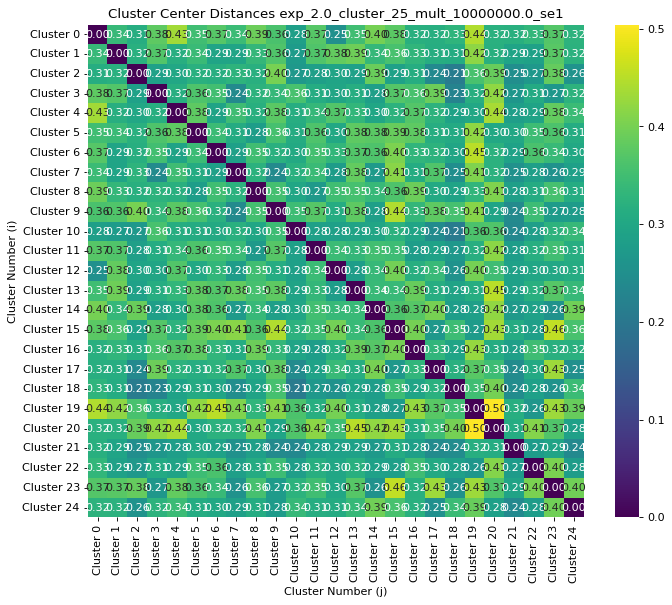

In [5]:
cluster_centers_epochs = np.load(f'/user/ninasophie.nellen/sensorium/tests/cluster_centers/cluster_centers_{path_ending}.npy')
#cluster_centers_epochs = np.load(f"/user/ninasophie.nellen/sensorium/tests/cluster_centers/cluster_centers_se{dec_starting_epcoch}_we{dec_wamup_epcoh}.npy")
#print(cluster_centers_epochs.shape)
cluster_numbers = cluster_centers_epochs.shape[1]
cluster_centers=cluster_centers_epochs[-1]
euclidian_distance = np.linalg.norm(cluster_centers,axis=1)
#print(cluster_centers)
print('Euclidian distance of the cluster centers and the 0 vector', euclidian_distance)

distance_matrix = np.zeros((cluster_numbers, cluster_numbers))

for i in range(cluster_numbers):
    for j in range(cluster_numbers):
        if i != j:
            distance_matrix[i, j] = np.linalg.norm(cluster_centers[i] - cluster_centers[j])  # Euclidean distance


# Step 2: Create a DataFrame to make it more interpretable
distance_df = pd.DataFrame(distance_matrix, 
                           index=[f'Cluster {i}' for i in range(cluster_numbers)], 
                           columns=[f'Cluster {j}' for j in range(cluster_numbers)])

# Step 3: Plot the distance table as a heatmap
plt.figure(figsize=(10, 8), dpi=80)
sns.heatmap(distance_df, annot=True, fmt=".2f", cmap="viridis", cbar=True)

plt.title(f'Cluster Center Distances exp_{exponent}_cluster_{clusters}_mult_{multiplier}_se{starting_epcoch}')
plt.xlabel('Cluster Number (j)')
plt.ylabel('Cluster Number (i)')

# Save the heatmap plot as a PNG file
plt.savefig(f'plots/cluster_center_distances_heatmap_{path_ending}.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

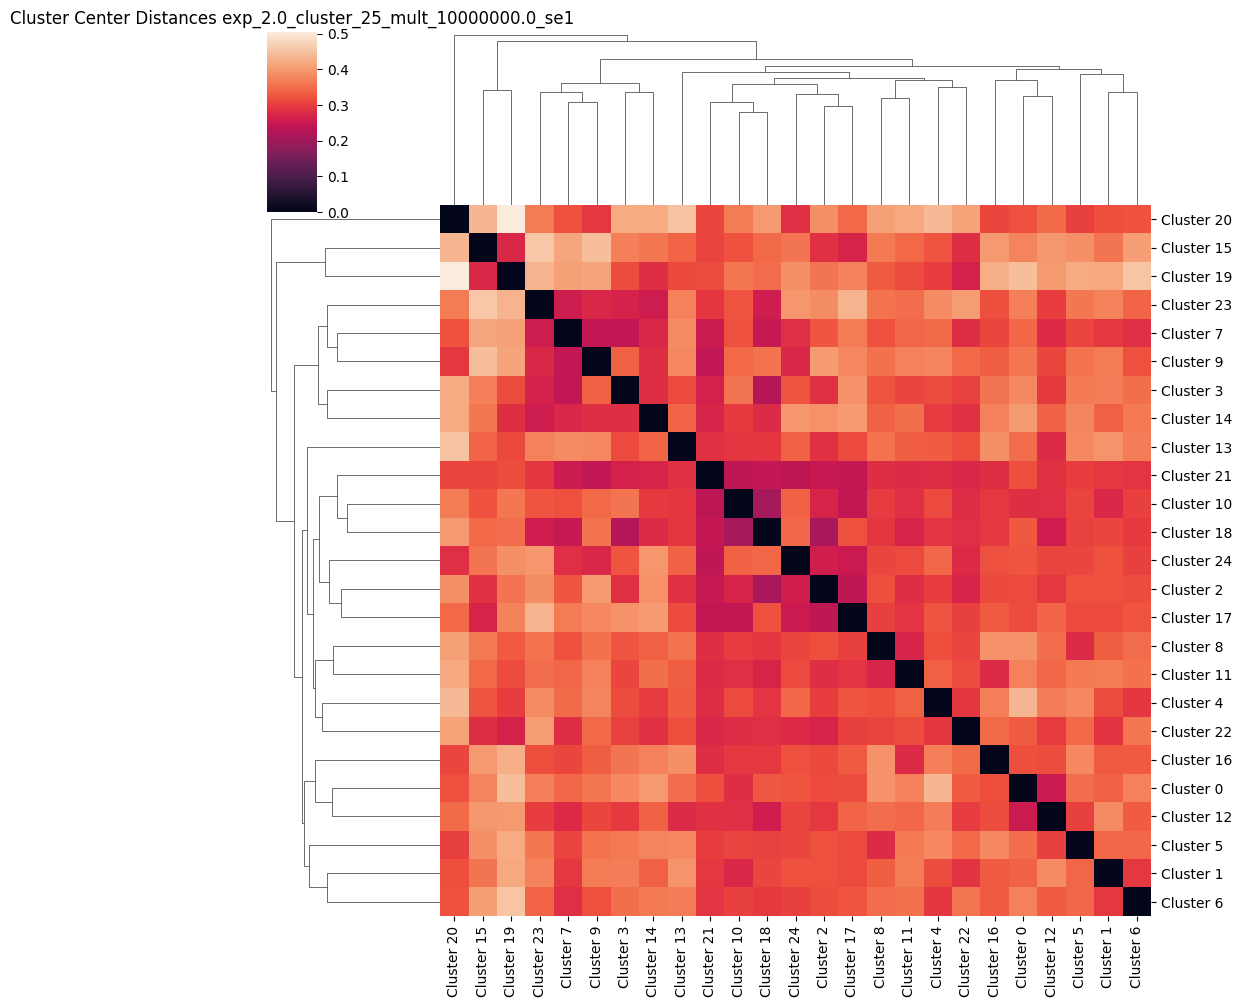

In [6]:
sns.clustermap(distance_df)
plt.title(f'Cluster Center Distances exp_{exponent}_cluster_{clusters}_mult_{multiplier}_se{starting_epcoch}')
#plt.savefig(f'plots/cluster_center_distances_clustermap_{path_ending}.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
predictions = torch.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_dec_{path_ending}.pt').cpu().numpy()
#torch.load(f"/user/ninasophie.nellen/sensorium/tests/predictions/predictions_dec_se{dec_starting_epcoch}_we{dec_wamup_epcoh}.pt").cpu().numpy()
print(predictions.shape)
unique_values, counts = np.unique(predictions, return_counts=True)
print(f"There are {counts} values of cluster {unique_values}")
for value, count in zip(unique_values, counts):
    print(f"Cluster {value} has {count} entries")

predictions    

(54569,)
There are [1802 1932 3258 1973 1734 1759 1904 2583 1934 2105 3214 2059 2110 2004
 2258 1353 1957 2648 2894 1441 1314 2953 2455 2386 2539] values of cluster [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Cluster 0 has 1802 entries
Cluster 1 has 1932 entries
Cluster 2 has 3258 entries
Cluster 3 has 1973 entries
Cluster 4 has 1734 entries
Cluster 5 has 1759 entries
Cluster 6 has 1904 entries
Cluster 7 has 2583 entries
Cluster 8 has 1934 entries
Cluster 9 has 2105 entries
Cluster 10 has 3214 entries
Cluster 11 has 2059 entries
Cluster 12 has 2110 entries
Cluster 13 has 2004 entries
Cluster 14 has 2258 entries
Cluster 15 has 1353 entries
Cluster 16 has 1957 entries
Cluster 17 has 2648 entries
Cluster 18 has 2894 entries
Cluster 19 has 1441 entries
Cluster 20 has 1314 entries
Cluster 21 has 2953 entries
Cluster 22 has 2455 entries
Cluster 23 has 2386 entries
Cluster 24 has 2539 entries


array([ 2,  3, 11, ..., 10, 11, 23])

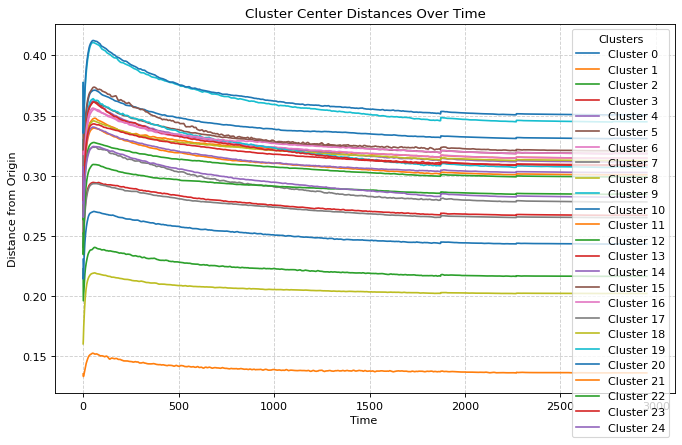

In [8]:
time = cluster_centers_epochs.shape[0]
cluster_centers_distances=np.zeros((time, cluster_numbers)) 

for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_epochs[batch],axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)

for cluster_idx in range(cluster_numbers):
    if cluster_idx in unique_values:
        plt.plot(range(time), cluster_centers_distances[:, cluster_idx], label=f'Cluster {cluster_idx}')

plt.xlabel('Time ')
plt.ylabel('Distance from Origin')
plt.title('Cluster Center Distances Over Time')
plt.legend(title='Clusters', loc='upper right', frameon=True)
plt.grid(True, linestyle='--',alpha=0.6)

# Save the plot
plt.savefig(f'plots/cluster_center_distances_form_origin_{path_ending}.png', dpi=300, bbox_inches='tight')
plt.show()


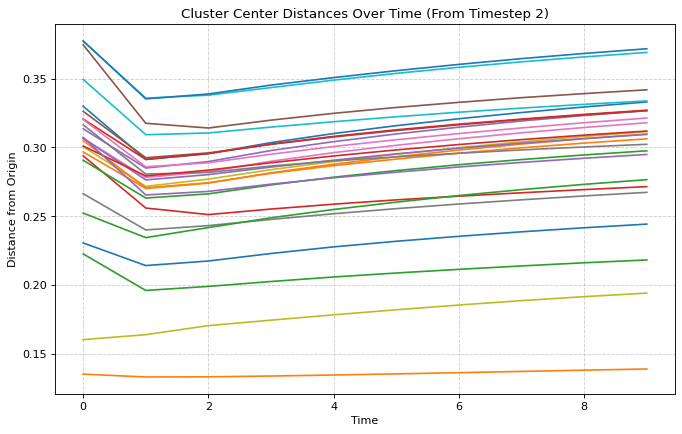

In [9]:
# Adjust the range of timesteps to start from 2
start_time = 0
end_time = 10
time = cluster_centers_epochs.shape[0]
cluster_centers_distances = np.zeros((time, cluster_numbers))

# Compute distances
for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_epochs[batch], axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)

for cluster_idx in range(cluster_numbers):
    if cluster_idx in unique_values:
        # Plot starting from timestep 2
        plt.plot(range(start_time, end_time), cluster_centers_distances[:end_time, cluster_idx], label=f'Cluster {cluster_idx}')

# Adjust x-axis limits to start from timestep 2
#plt.xlim(start_time, time - 1)
plt.xlabel('Time')
plt.ylabel('Distance from Origin')
plt.title('Cluster Center Distances Over Time (From Timestep 2)')
#plt.legend(title='Clusters', loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Save and show the plot
plt.savefig(f'plots/cluster_center_distances_from_timestep2_{path_ending}.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
for i in range(cluster_numbers):
    for j in range(i,cluster_numbers):
        if i != j:
            print(distance_matrix[i,j])
            if abs(distance_matrix[i, j]) < 1e-2:
                predictions[predictions == j] = i  # Replace cluster j values with i

print("Updated Predictions:", predictions)
unique_values, counts = np.unique(predictions, return_counts=True)
print(f"There are {counts} values of cluster {unique_values}")
for value, count in zip(unique_values, counts):
    print(f"Cluster {value} has {count} entries")

predictions    

0.33853796124458313
0.3147232234477997
0.37901076674461365
0.43380334973335266
0.35033732652664185
0.37151452898979187
0.343063622713089
0.3917974531650543
0.35974276065826416
0.2833898067474365
0.3715488910675049
0.25187256932258606
0.3487391769886017
0.3990725576877594
0.3758816719055176
0.317802369594574
0.31517088413238525
0.3277900815010071
0.44459834694862366
0.31911319494247437
0.31730902194976807
0.3319104015827179
0.3694823682308197
0.3241131901741028
0.3200378119945526
0.367444783449173
0.3158422112464905
0.3408336341381073
0.29499489068984985
0.29476404190063477
0.3338134288787842
0.36495697498321533
0.2747477889060974
0.36623331904411316
0.3835567831993103
0.3920767605304718
0.33654579520225525
0.3573576807975769
0.3307482600212097
0.31451350450515747
0.3098995089530945
0.4182838499546051
0.3172360956668854
0.29414063692092896
0.28758683800697327
0.37370261549949646
0.32300883531570435
0.28698569536209106
0.2994244396686554
0.3197721540927887
0.3156026005744934
0.3268225789

array([ 2,  3, 11, ..., 10, 11, 23])

In [11]:
# loading the SENSORIUM+ dataset
pre = "/usr/users/agecker/datasets/sensorium_2022_pictures/real_dataset/"
filenames = [f"{pre}{i}/" for i in os.listdir(pre)]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
model_fn = 'sensorium.models.stacked_core_full_gauss_readout'
model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 10,
  'hidden_kern': 7,
  'hidden_channels': 128,
  'depth_separable': True,
  'grid_mean_predictor': {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True
   },
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': True,
  'regularizer_type': 'adaptive_log_norm',
  #'feature_reg_weight': 10,
}
model = get_model(
    model_fn=model_fn,
    model_config=model_config,
    dataloaders=dataloaders,
    seed=42,
)

In [12]:
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_{path_ending}.pth'
#save_path = f"/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_se{dec_starting_epcoch}_we{dec_wamup_epcoh}.pth"
model.load_state_dict(torch.load(save_path),strict=False)

<All keys matched successfully>

In [13]:
# Initialize variables
features_list = []  # List to store features
colors = []  # To store colors for visualization


for k, readout in model.readout.items():
    # Extract features and their shape
    features = readout.features.cpu().detach().squeeze().T.numpy()
    features_list.append(features)  # Append the full features to the list

features_list = np.vstack(features_list)
random_indices_predicted = np.load("random_indices_predicted.npy")


# Create predictions_subset using the consistent indices
predictions_subset = predictions[random_indices_predicted]
print(predictions_subset.shape)

unique_values = np.unique(predictions_subset)
num_clusters = len(unique_values) 

# Combine all subsets into a single array for t-SNE
combined_features = features_list[random_indices_predicted]
n = combined_features.shape[0]

(14000,)


TSNE plot with cluster centers

(14000, 128)


<Figure size 640x800 with 0 Axes>

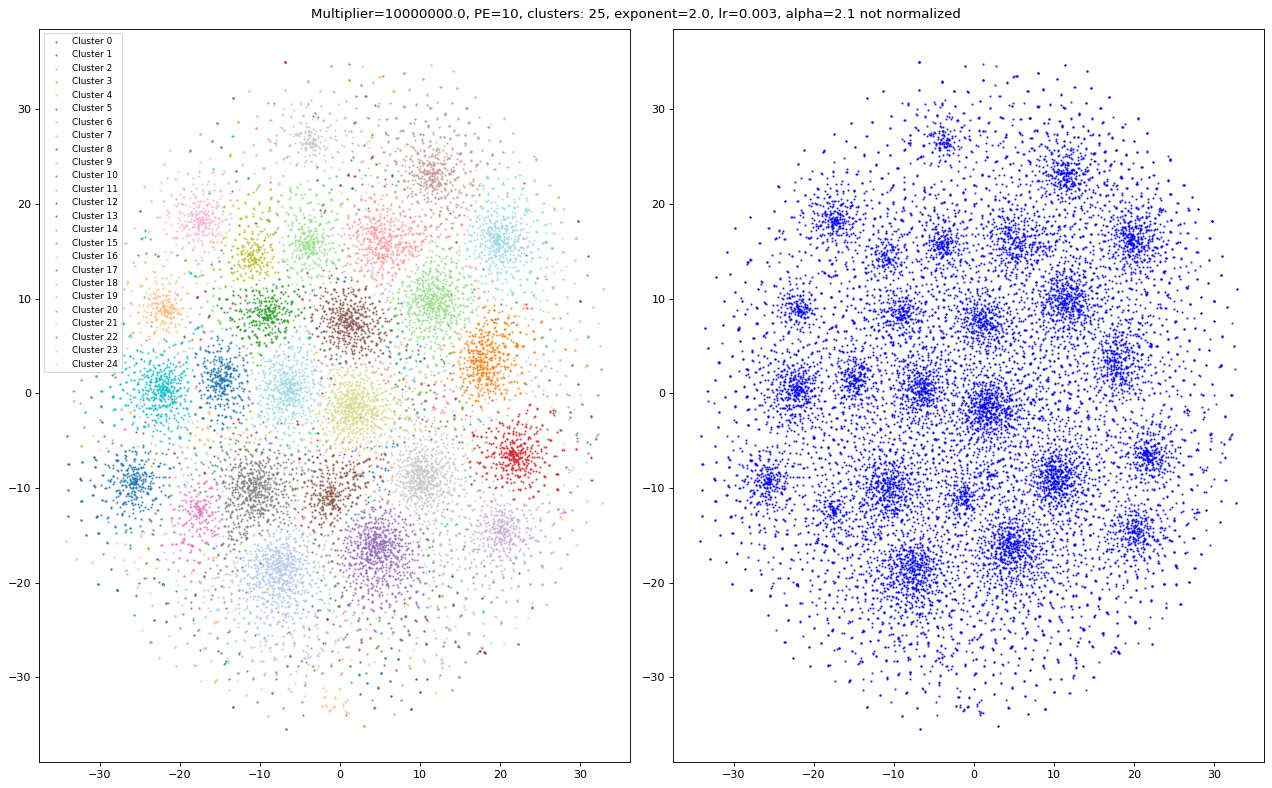

In [14]:
perplexity = n / 100
lr = n / 12

np.random.seed(42)
plt.figure(figsize=(8,10), dpi=80)
fig, axes = plt.subplots(1,2, figsize=(16, 10), dpi=80)  # 2x4 grid in each figure


unique_values = np.unique(predictions_subset)
colors = plt.cm.get_cmap("tab20", len(unique_values))
color_map = {label: colors(i) for i, label in enumerate(unique_values)}

#combined_features=combined_features[:2000][:]
print(combined_features.shape)
combined_data = np.vstack([combined_features, cluster_centers])  # Stack features with centers

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

# Split the result back into original points and cluster centers
n_samples = combined_features.shape[0]
embedded_points = embedded_data[:n_samples]  # First part corresponds to data points
embedded_centers = embedded_data[n_samples:]  # Last part corresponds to cluster centers

# **Subplot 1: Colored Clusters**
for value in unique_values:
    cluster_mask = predictions_subset == value
    axes[0].scatter(
        embedded_points[cluster_mask, 0],
        embedded_points[cluster_mask, 1],
        c=[color_map[value]],  # Mapped color
        label=f'Cluster {value}',
        alpha=0.7,
        s=1,
    )
    
    '''
    axes[0].scatter(
        embedded_centers[value, 0],
        embedded_centers[value, 1],
        c=[color_map[value]],
        marker='X',
        s=100,
        edgecolor='black',
        label=f'Center {value}'
    )
    '''
    
axes[0].legend(fontsize=8, loc='upper left',)

# **Subplot 2: Single-Color**
axes[1].scatter(
    embedded_points[:, 0],
    embedded_points[:, 1],
    c="blue",  # Single color
    alpha=0.7,
    s=1,
)

fig.suptitle(f'Multiplier={multiplier}, PE={pretrain_epoch}, clusters: {clusters}, exponent={exponent}, lr={lr_model}, alpha={alpha} not normalized')

plt.savefig(f'plots/tsne_model_wo_rotation_{path_ending}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi

# Adjust layout and show
plt.tight_layout()
plt.show()

<Figure size 600x800 with 0 Axes>

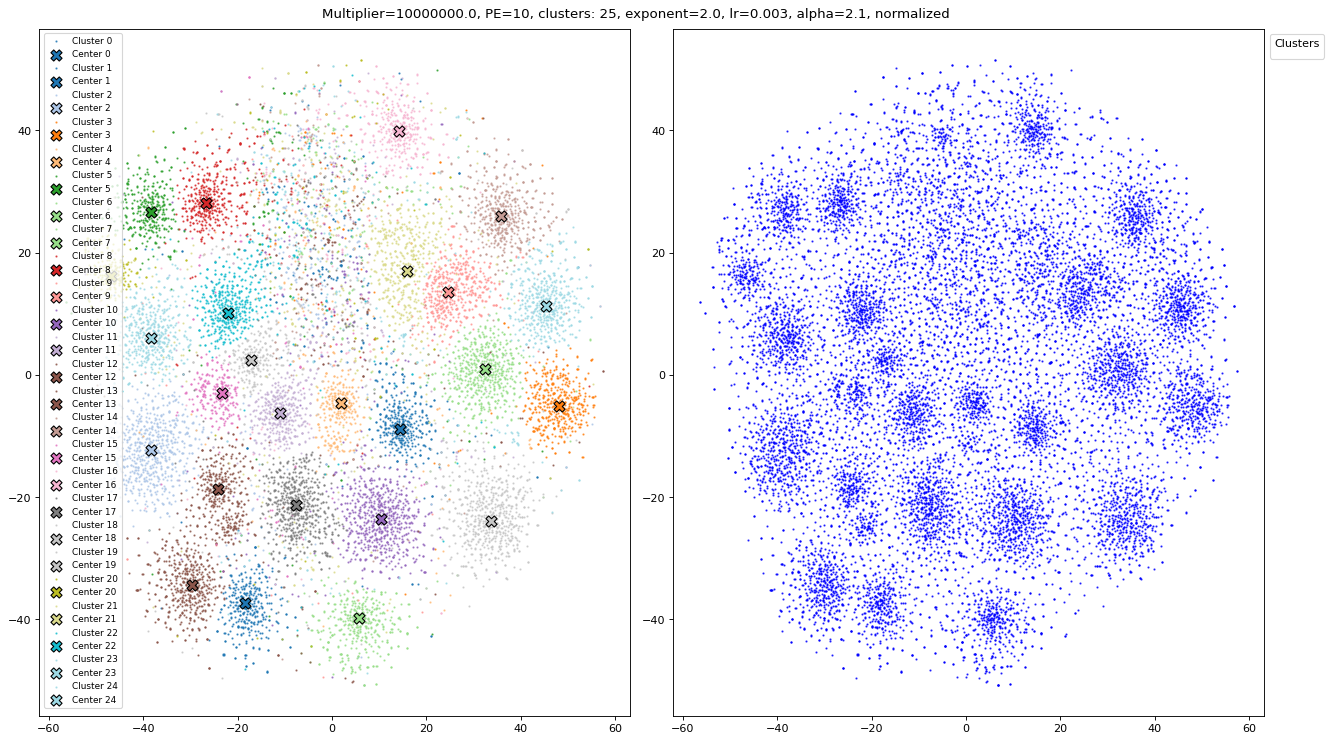

In [15]:
perplexity = 100
n/100
#[30, 50, 100, n/100]
learning_rates = [n/12]
#[10,100,1000,n/12]
lr = n/12

plt.figure(figsize=(7.5,10), dpi=80)

fig, axes = plt.subplots(1,2, figsize=(16, 10), dpi=80)  # 2x4 grid in each figure

unique_values = np.unique(predictions_subset)
colors = plt.cm.get_cmap("tab20", len(unique_values))
color_map = {label: colors(i) for i, label in enumerate(unique_values)}

combined_data = np.vstack([combined_features, cluster_centers])  # Stack features with centers
Y = combined_data / np.linalg.norm(combined_data, axis=1,  keepdims=True)
combined_data = Y.copy()

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

# Split the result back into original points and cluster centers
n_samples = combined_features.shape[0]
embedded_points = embedded_data[:n_samples]  # First part corresponds to data points
embedded_centers = embedded_data[n_samples:]  # Last part corresponds to cluster centers

# **Subplot 1: Colored Clusters**
for value in unique_values:
    cluster_mask = predictions_subset == value
    axes[0].scatter(
        embedded_points[cluster_mask, 0],
        embedded_points[cluster_mask, 1],
        c=[color_map[value]],  # Mapped color
        label=f'Cluster {value}',
        alpha=0.7,
        s=1,
    )
    
    axes[0].scatter(
        embedded_centers[value, 0],
        embedded_centers[value, 1],
        c=[color_map[value]],
        marker='X',
        s=100,
        edgecolor='black',
        label=f'Center {value}'
    )
    
axes[0].legend(fontsize=8, loc='upper left',)

# **Subplot 2: Single-Color**
axes[1].scatter(
    embedded_points[:, 0],
    embedded_points[:, 1],
    c="blue",  # Single color
    alpha=0.7,
    s=1,
)
fig.suptitle(f'Multiplier={multiplier}, PE={pretrain_epoch}, clusters: {clusters}, exponent={exponent}, lr={lr_model}, alpha={alpha}, normalized')


plt.tight_layout()

# Add legend automatically from the scatter plot
plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
#plt.savefig(f'plots/tsne_model_wo_rotation_{path_ending}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi
plt.show()

## Color by mice

<Figure size 640x800 with 0 Axes>

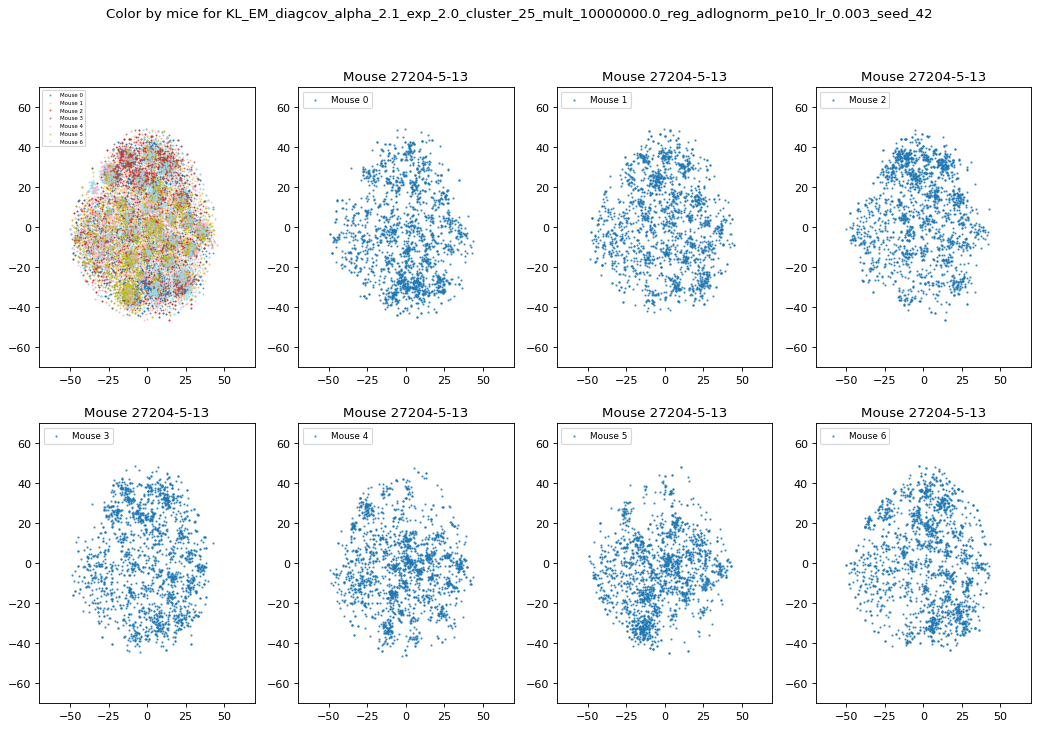

In [16]:
perplexity = n/100
lr = n/12

plt.figure(figsize=(8,10), dpi=80)

Y = combined_features/ np.linalg.norm(combined_features, axis=1,  keepdims=True)
combined_features = Y.copy()

# Create a new figure for each plot
fig, ax = plt.subplots(2, 4, figsize=(16, 10), dpi=80)  # 2x4 grid in each figure

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_points = tsne.fit_transform(combined_features)  # Run on combined data

# Parameters
total_points = len(embedded_points)  # Total number of points
group_size = 2000  # Group size for each color
num_groups = 7

colors = plt.cm.get_cmap("tab20", num_groups)  # Dynamically create colormap
color_map = {group: colors(group) for group in range(num_groups)}
point_groups = np.arange(total_points) // group_size  # Assign each point a group


# Plot points with group colors
for group in range(num_groups):
    group_mask = point_groups == group

    ax[0,0].scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        c=[color_map[group]],  # Use color from the colormap
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=0.5,  # Size of points
    )
    ax[0,0].set_xlim(-70, 70)
    ax[0,0].set_ylim(-70, 70)
    ax[0,0].legend(fontsize=5, loc='upper left')


# Plot points with group colors
for group in range(num_groups):
    idx = group + 1
    
    group_mask = point_groups == group
    # Find the subplot position
    row = idx // 4  # Calculate row index (0 or 1)
    col = idx % 4   # Calculate column index (0 to 3)

    # Select the subplot location
    ax[row, col].scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=1,  # Size of points
    )

    # Customize the plot
    ax[row, col].set_title(f'Mouse {k}')
    ax[row, col].set_xlim(-70, 70)
    ax[row, col].set_ylim(-70, 70)
    ax[row, col].legend(fontsize=8, loc='upper left',)


plt.suptitle(f'Color by mice for {path_ending}')
# plt.title(f'Color by mice with Perplexity={perplexity}, Multiplier={multiplier}, SE={starting_epcoch}, clusters: {clusters}, exponent={exponent}')
#plt.legend()
plt.show()

In [ ]:
perplexity = n/100
lr = n/12

plt.figure(figsize=(8,10), dpi=80)

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_points = tsne.fit_transform(combined_features)  # Run on combined data

# Parameters
total_points = len(embedded_points)  # Total number of points
group_size = 2000  # Group size for each color
num_groups = 7

colors = plt.cm.get_cmap("tab20", num_groups)  # Dynamically create colormap
color_map = {group: colors(group) for group in range(num_groups)}
point_groups = np.arange(total_points) // group_size  # Assign each point a group


# Plot points with group colors
for group in range(num_groups):
    group_mask = point_groups == group

    plt.scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        c=[color_map[group]],  # Use color from the colormap
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=0.5,  # Size of points
    )
    plt.legend(fontsize=5, loc='upper left')

### Plots for indivual mice

In [39]:
perplexity = n/100
lr = n/12

for idx, (k, readout) in enumerate(model.readout.items()):
    idx = idx +1
    # Extract features and convert to numpy
    features = readout.features.cpu().detach().squeeze().T.numpy()

    # Perform t-SNE embedding
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
    embedded_points = tsne.fit_transform(features)

    # Find the subplot position
    row = idx // 4  # Calculate row index (0 or 1)
    col = idx % 4   # Calculate column index (0 to 3)

    # Select the subplot location
    ax[row, col].scatter(
        embedded_points[:, 0],  # X coordinates
        embedded_points[:, 1],  # Y coordinates
        label=f'Mouse {k}',
        alpha=0.7,  # Transparency
        s=1,  # Size of points
    )

    # Customize the plot
    ax[row, col].set_title(f'Mouse {k}')
    ax[row, col].set_xlim(-0.3, 0.3)
    ax[row, col].set_ylim(-0.3, 0.3)
    ax[row, col].legend(fontsize=8)

plt.show()
    

<Figure size 640x800 with 0 Axes>

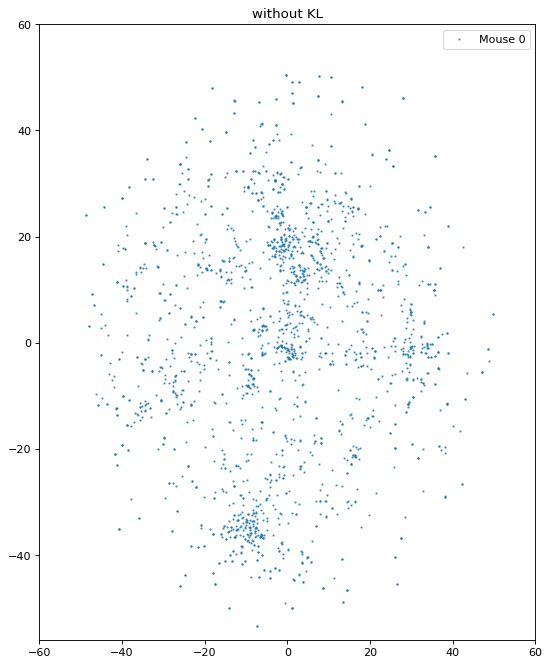

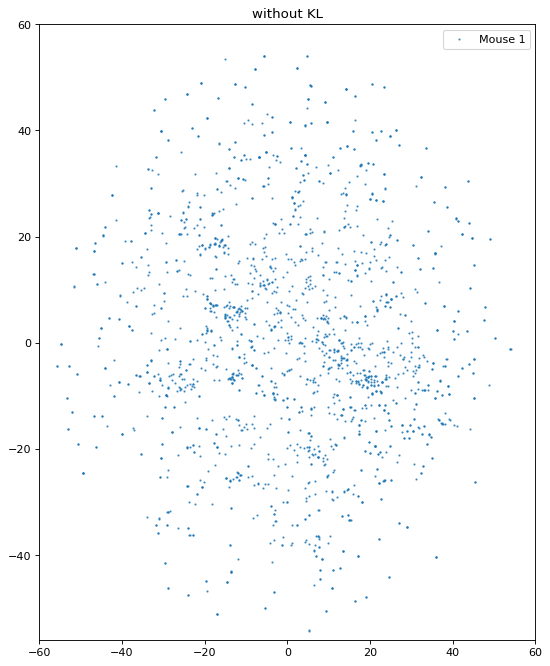

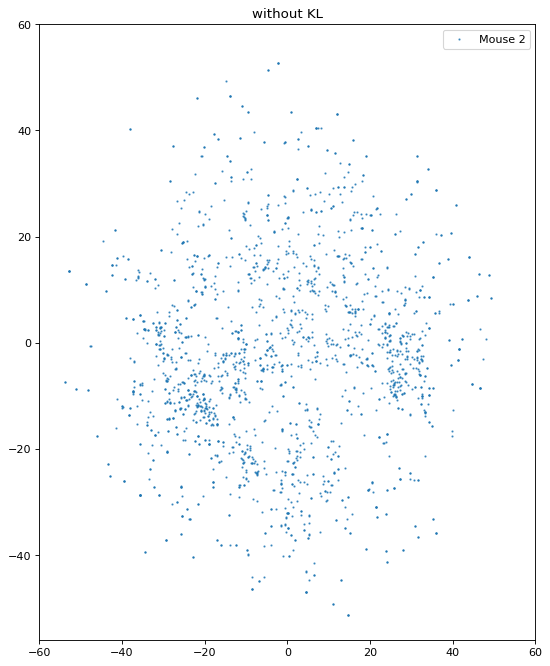

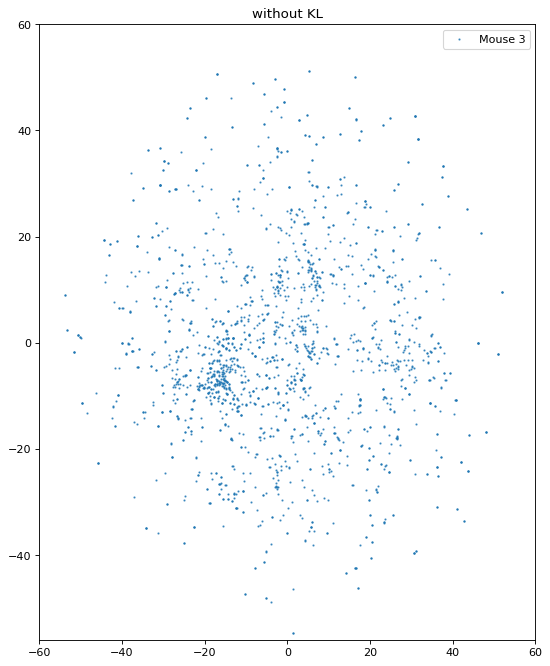

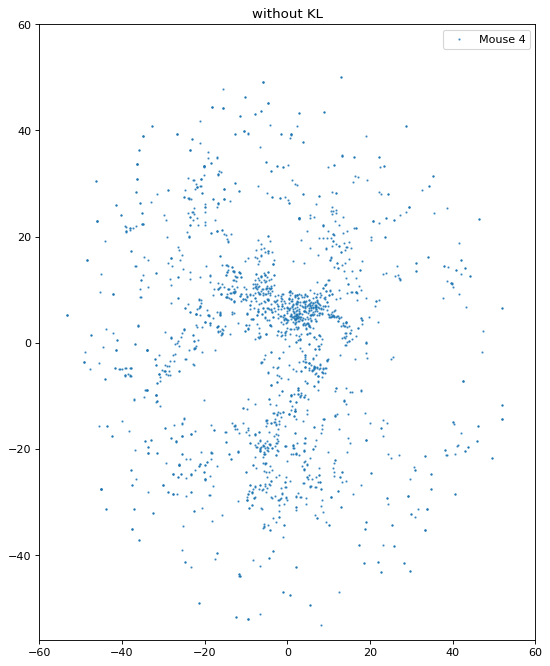

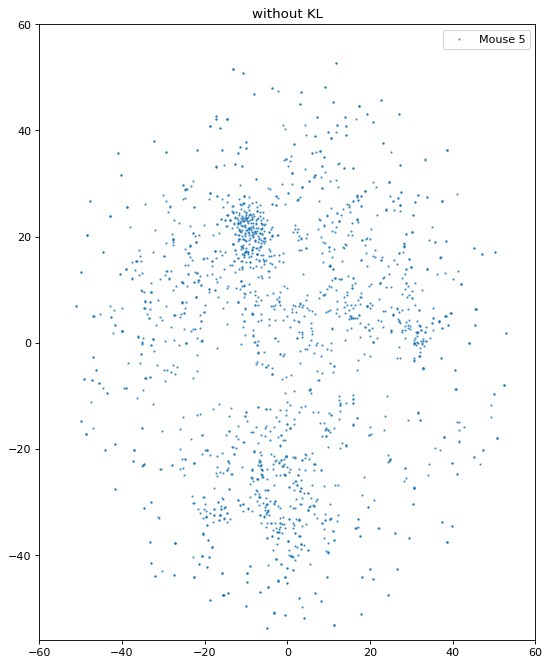

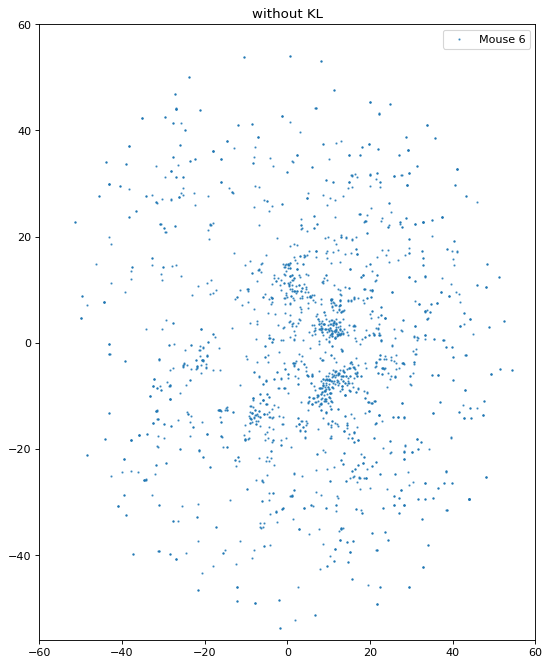

In [14]:
perplexity = n/100
lr = n/12

plt.figure(figsize=(8,10), dpi=80)

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_points = tsne.fit_transform(combined_features)  # Run on combined data

# Parameters
total_points = len(embedded_points)  # Total number of points
group_size = 2000  # Group size for each color
num_groups = 7

colors = plt.cm.get_cmap("tab20", num_groups)  # Dynamically create colormap
color_map = {group: colors(group) for group in range(num_groups)}
point_groups = np.arange(total_points) // group_size  # Assign each point a group


# Plot points with group colors
for group in range(num_groups):
    plt.figure(figsize=(8,10), dpi=80)
    
    group_mask = point_groups == group

    plt.scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=1,  # Size of points
    )

    plt.title('without KL')
    plt.xlim(-60, 60)
    plt.ylim(-56, 60)
    # plt.title(f'Color by mice with Perplexity={perplexity}, Multiplier={multiplier}, SE={starting_epcoch}, clusters: {clusters}, exponent={exponent}')
    plt.legend()
    plt.show()

Code for predictions

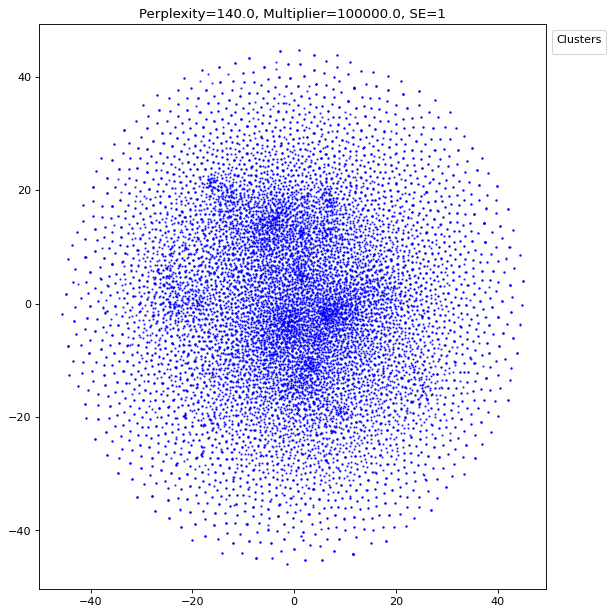

In [13]:
# Fixed Perplexity and Learning Rate
perplexity_values = [n / 100]
learning_rates = [n / 12]
lr = n / 12

# Set up the plot
plt.figure(figsize=(20, 15), dpi=80)

for i, perplexity in enumerate(perplexity_values):
    # Combine features and cluster centers for t-SNE
    combined_data = np.vstack([combined_features, cluster_centers])  # Stack features with centers
    
    # Apply t-SNE to combined data
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
    embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

    # Split the result back into original points and cluster centers
    n_samples = combined_features.shape[0]
    embedded_points = embedded_data[:n_samples]  # First part corresponds to data points
    embedded_centers = embedded_data[n_samples:]  # Last part corresponds to cluster centers

    # Create a subplot for each perplexity
    plt.subplot(2, 3, i + 1)  # Correct subplot indexing

    # Define a single color for all clusters
    single_color = 'blue'

    for label in unique_values:
        cluster_mask = predictions_subset == label  # Mask for the current cluster
        
        # Scatter plot for all points (same color)
        plt.scatter(
            embedded_points[cluster_mask, 0], embedded_points[cluster_mask, 1],
            c=single_color, alpha=0.7, s=1
        )
        # Plot cluster centers (same color, marked as X)
        '''
        plt.scatter(
            embedded_centers[label][0], embedded_centers[label][1], 
            c=single_color, marker='X', s=100, edgecolor='black'
        )
        '''

    
    plt.title(f'Perplexity={perplexity}, Multiplier={multiplier}, SE={starting_epcoch}')

# Adjust layout for better spacing
plt.tight_layout()

# Add legend automatically from the scatter plot
plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
#plt.savefig(f'plots/tsne_model_wo_rotation_adaptlognorm_mult_{multiplier}se{starting_epcoch}_we{dec_wamup_epcoh}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi
plt.show()

Giff

In [ ]:
# Create a directory to store the individual heatmap frames
os.makedirs('heatmap_frames', exist_ok=True)

# Assuming cluster_centers_epochs is of shape (time, num_clusters, num_features)
time = cluster_centers_epochs.shape[0]
num_clusters = cluster_centers_epochs.shape[1]

# Loop to calculate distances and plot the heatmap for each epoch
for batch in range(time):
    # Step 1: Calculate the distance matrix for the current batch
    distance_matrix = np.zeros((num_clusters, num_clusters))
    for i in range(num_clusters):
        for j in range(num_clusters):
            if i != j:
                distance_matrix[i, j] = np.linalg.norm(cluster_centers_epochs[batch][i] - cluster_centers_epochs[batch][j])  # Euclidean distance

    # Step 2: Create a DataFrame to make it more interpretable
    distance_df = pd.DataFrame(distance_matrix, 
                               index=[f'Cluster {i}' for i in range(num_clusters)], 
                               columns=[f'Cluster {j}' for j in range(num_clusters)])

    # Step 3: Plot the distance table as a heatmap
    plt.figure(figsize=(10, 8), dpi=80)
    sns.heatmap(distance_df, annot=True, fmt=".2f", cmap="viridis", cbar=True)
    plt.title(f'Cluster Center Distances (Epoch {batch+1}/{time})')
    plt.xlabel('Cluster Number (j)')
    plt.ylabel('Cluster Number (i)')

    # Save each frame as an image
    frame_path = f'heatmap_frames/heatmap_epoch_{batch}.png'
    plt.savefig(frame_path, dpi=150, bbox_inches='tight')
    plt.close()  # Close the figure to free up memory

# Step 4: Create the GIF from saved frames
frames = []
for batch in range(time):
    frame_path = f'heatmap_frames/heatmap_epoch_{batch}.png'
    image = Image.open(frame_path)
    frames.append(image)

# Save the GIF
gif_path = 'plots/cluster_distance_heatmap.gif'
frames[0].save(
    gif_path, 
    save_all=True, 
    append_images=frames[1:], 
    duration=500,  # Duration of each frame in milliseconds
    loop=0  # Loop forever
)

print(f"GIF saved at {gif_path}")

TSNE plot without cluster centers

In [7]:
perplexity_values = 50
#[n/100]
#[30, 50, 100, n/100]
learning_rates = [n/12]
#[10,100,1000,n/12]
lr = n/12

# Create a plot for each perplexity value
plt.figure(figsize=(20, 20), dpi=80)

for i, perplexity in enumerate(perplexity_values):
    #for j, lr in enumerate(learning_rates):
        # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)  # Adjust perplexity as needed
    embedded_data = tsne.fit_transform(combined_features)

    # Create a subplot for each perplexity
    plt.subplot(2,3, i + 1)  # Correct subplot indexing
    for label in unique_values:
        cluster_mask = predictions_subset == label  # Mask for the current cluster
        plt.scatter(
            embedded_data[cluster_mask, 0], embedded_data[cluster_mask, 1],
            c=[label_to_color[label]], label=f'Cluster {label}', alpha=0.7, s=1
        )
    plt.title(f'Perplexity={perplexity}')

# Adjust layout for better spacing
plt.tight_layout()

# Add legend automatically from the scatter plot
plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.show()


TypeError: 'int' object is not iterable

<Figure size 1600x1600 with 0 Axes>

In [19]:
plt.savefig(f'plots/tsne_model_wo_rotation_adaptlognorm_mult_{multiplier}se{dec_starting_epcoch}_we{dec_wamup_epcoh}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi
plt.show()

<Figure size 640x480 with 0 Axes>

Create subset of indices

In [ ]:
# Initialize variables
features_list = []  # List to store features
random_indices = []  # To store consistent indices
features_subset = []  # To store subsets of features
colors = []  # To store colors for visualization
features_shape_previous = 0
i = 0

for k, readout in model.readout.items():
    # Extract features and their shape
    features = readout.features.cpu().detach().squeeze().T.numpy()
    features_list.append(features)  # Append the full features to the list
    print(f"Features for readout {k}: {features.shape}")
    if len(random_indices) <= i:
        # Generate random indices only for the first pass
        random_indices.append(np.random.choice(features.shape[0], size=2000, replace=False))
    
    # Select subset of features using consistent indices
    current_indices = random_indices[i]
    features_subset.append(features[current_indices, :])
    
    # Update predictions subset indices
    global_indices = current_indices + features_shape_previous
    features_shape_previous += features.shape[0]
    
    i += 1

random_indices_predicted = np.concatenate([indices + sum(len(f) for f in features_list[:i]) 
                                           for i, indices in enumerate(random_indices)])

# Create predictions_subset using the consistent indices
predictions_subset = predictions[random_indices_predicted]
print(predictions_subset.shape)

unique_values = np.unique(predictions_subset)
num_clusters = len(unique_values) 

# Combine all subsets into a single array for t-SNE
combined_features = np.vstack(features_subset)
n = combined_features.shape[0]